In [ ]:

# Number of taxi pickups occurring in a zone during a specific hour.

In [2]:
import pandas as pd

In [3]:
df = pd.read_parquet(
    "/home/ed/Desktop/TS-Forecasting/data/yellow_tripdata_2026-01.parquet"
)

In [4]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,NaN,237,161,0,17.09,0.00,0.5,0.00,0.0,1.0,21.84,NaN,NaN,0.75
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,NaN,42,42,0,23.19,0.00,0.5,0.00,0.0,1.0,24.69,NaN,NaN,0.00
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,NaN,137,69,0,29.21,0.00,0.5,0.00,0.0,1.0,33.96,NaN,NaN,0.75
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,NaN,137,162,0,19.19,0.00,0.5,0.00,0.0,1.0,23.94,NaN,NaN,0.75


In [5]:
# %pip install pyarrow
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')

In [6]:
df.shape

(3724889, 20)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [8]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.724889e+06,3724889,3724889,2.636831e+06,3.724889e+06,2.636831e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,2.636831e+06,2.636831e+06,3.724889e+06
mean,1.873598e+00,2026-01-17 01:44:52.106518,2026-01-17 02:02:03.696138,1.256271e+00,6.455647e+00,5.218853e+00,1.614372e+02,1.609936e+02,8.465637e-01,2.080425e+01,1.023055e+00,4.833766e-01,2.608142e+00,4.983751e-01,9.479130e-01,2.917853e+01,2.154870e+00,1.482938e-01,5.196437e-01
min,1.000000e+00,2025-12-31 23:57:29,2025-12-31 23:57:32,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.555200e+03,-7.500000e+00,-5.000000e-01,-8.888000e+01,-9.450000e+01,-1.000000e+00,-2.560200e+03,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2026-01-09 17:51:59,2026-01-09 18:08:47,1.000000e+00,1.000000e+00,1.000000e+00,1.140000e+02,1.070000e+02,0.000000e+00,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2026-01-16 21:20:56,2026-01-16 21:36:14,1.000000e+00,1.810000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.560000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.305000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2026-01-24 07:25:11,2026-01-24 07:40:22,1.000000e+00,3.730000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.610000e+01,2.500000e+00,5.000000e-01,3.710000e+00,0.000000e+00,1.000000e+00,3.383000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2026-02-01 00:45:01,2026-02-01 23:35:31,9.000000e+00,2.690975e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,2.555200e+03,1.746000e+01,4.750000e+00,7.660000e+02,1.222200e+02,1.000000e+00,2.560200e+03,2.500000e+00,2.675000e+01,7.500000e-01
std,7.014583e-01,NaN,NaN,6.702431e-01,6.488855e+02,1.965370e+01,6.706657e+01,7.103604e+01,7.120493e-01,1.892701e+01,1.707322e+00,1.145558e-01,3.917405e+00,2.131731e+00,2.654859e-01,2.258553e+01,9.423645e-01,5.336714e-01,3.568099e-01


In [9]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [10]:
df.sample(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3499741,2,2026-01-27 14:32:00,2026-01-27 15:30:00,NaN,2.50,NaN,NaN,164,236,0,30.20,0.0,0.5,0.0,0.0,1.0,34.95,NaN,NaN,0.75
3487003,2,2026-01-27 07:44:03,2026-01-27 07:55:51,NaN,1.62,NaN,NaN,95,95,0,29.36,0.0,0.5,0.0,0.0,1.0,30.86,NaN,NaN,0.00
1443163,2,2026-01-17 15:16:37,2026-01-17 15:16:43,1.0,0.00,1.0,N,197,197,2,-3.00,0.0,-0.5,0.0,0.0,-1.0,-4.50,0.0,0.0,0.00
2848409,2,2026-01-08 19:22:35,2026-01-08 19:32:57,NaN,0.00,NaN,NaN,148,79,0,10.12,0.0,0.5,0.0,0.0,1.0,14.87,NaN,NaN,0.75
3615574,2,2026-01-30 01:49:52,2026-01-30 02:19:40,NaN,14.24,NaN,NaN,186,242,0,49.20,0.0,0.5,0.0,0.0,1.0,53.95,NaN,NaN,0.75


In [11]:
# Stage 1: Creating the Demand Dataset
    # How many pickups happened in Zone 161 between 10:00 and 11:00?
# because demand is simply:
# Count of pickups

# EDA


In [12]:
# Without Copy Later its show :SettingWithCopyWarning
forecast_df = df[
    ['tpep_pickup_datetime', 'PULocationID']
].copy()

In [13]:
forecast_df.head()

,tpep_pickup_datetime,PULocationID
0,2026-01-01 00:54:04,239
1,2026-01-01 00:34:04,163
2,2026-01-01 00:57:06,43
3,2026-01-01 00:15:22,142
4,2026-01-01 00:27:13,88


In [14]:
forecast_df.isnull().sum()

tpep_pickup_datetime    0
PULocationID            0
dtype: int64

In [15]:
forecast_df.duplicated().sum()
# Reason:They represent valid demand observations.

np.int64(125938)

In [16]:
# Reason:To group trips by hour for demand forecasting.
forecast_df['hour'] = (
    forecast_df['tpep_pickup_datetime']
    .dt.floor('h')
)

In [17]:
forecast_df['hour'].sample(10)

2567954   2026-01-31 10:00:00
3325829   2026-01-22 20:00:00
2817887   2026-01-07 14:00:00
1069847   2026-01-13 19:00:00
1753330   2026-01-21 11:00:00
3559819   2026-01-28 21:00:00
293028    2026-01-05 06:00:00
1326875   2026-01-16 11:00:00
2217108   2026-01-27 14:00:00
2780925   2026-01-05 20:00:00
Name: hour, dtype: datetime64[us]

In [18]:
# Create the hourly demand dataset:
hourly_demand = (
    forecast_df
    .groupby(['hour', 'PULocationID'])
    .size()
    .reset_index(name='demand')
)
print(hourly_demand.sample(20))

                      hour  PULocationID  demand
60059  2026-01-16 06:00:00           135       1
81385  2026-01-21 14:00:00           125      17
122324 2026-01-31 16:00:00           265       3
41738  2026-01-11 13:00:00           249     114
15605  2026-01-04 21:00:00           211      27
2145   2026-01-01 11:00:00            78       1
18864  2026-01-05 17:00:00            41      29
90048  2026-01-23 18:00:00           230     254
26179  2026-01-07 14:00:00           179       9
84085  2026-01-22 08:00:00            61      15
79128  2026-01-21 01:00:00             7       5
33626  2026-01-09 12:00:00            95      10
59178  2026-01-15 23:00:00           254       2
24839  2026-01-07 07:00:00           182      15
111793 2026-01-29 06:00:00           185       8
120109 2026-01-31 04:00:00           116       7
111570 2026-01-29 05:00:00           155       1
18267  2026-01-05 13:00:00           239     188
42748  2026-01-11 19:00:00           234     147
14740  2026-01-04 16

In [19]:
hourly_demand

,hour,PULocationID,demand
0,2025-12-31 23:00:00,113,1
1,2025-12-31 23:00:00,132,3
2,2025-12-31 23:00:00,163,1
3,2025-12-31 23:00:00,164,1
4,2026-01-01 00:00:00,3,2
...,...,...,...
123598,2026-01-31 23:00:00,261,29
123599,2026-01-31 23:00:00,262,59
123600,2026-01-31 23:00:00,263,175
123601,2026-01-31 23:00:00,264,5


In [20]:

hourly_demand.info()
hourly_demand.describe()

<class 'pandas.DataFrame'>
RangeIndex: 123603 entries, 0 to 123602
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   hour          123603 non-null  datetime64[us]
 1   PULocationID  123603 non-null  int32         
 2   demand        123603 non-null  int64         
dtypes: datetime64[us](1), int32(1), int64(1)
memory usage: 2.4 MB


,hour,PULocationID,demand
count,123603,123603.000000,123603.000000
mean,2026-01-16 14:39:52.631247,138.330639,30.135911
min,2025-12-31 23:00:00,1.000000,1.000000
25%,2026-01-08 19:00:00,72.000000,2.000000
50%,2026-01-16 15:00:00,140.000000,5.000000
75%,2026-01-24 11:00:00,209.000000,20.000000
max,2026-02-01 00:00:00,265.000000,798.000000
std,NaN,76.288627,65.045014


In [ ]:
# %pip install matplotlib


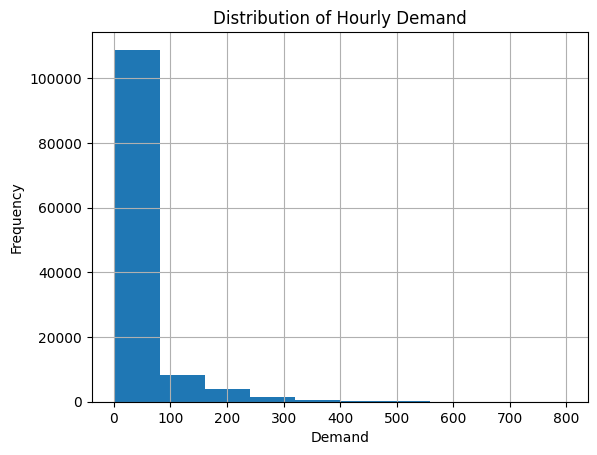

In [22]:
# To understand how demand values are distributed.
import matplotlib.pyplot as plt
hourly_demand['demand'].hist()

plt.title('Distribution of Hourly Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

In [38]:
citywide_demand = (
    hourly_demand
    .groupby('hour')['demand']
    .sum()
    .reset_index()
)
citywide_demand.head()

,hour,demand
0,2025-12-31 23:00:00,6
1,2026-01-01 00:00:00,9294
2,2026-01-01 01:00:00,10254
3,2026-01-01 02:00:00,7853
4,2026-01-01 03:00:00,6529


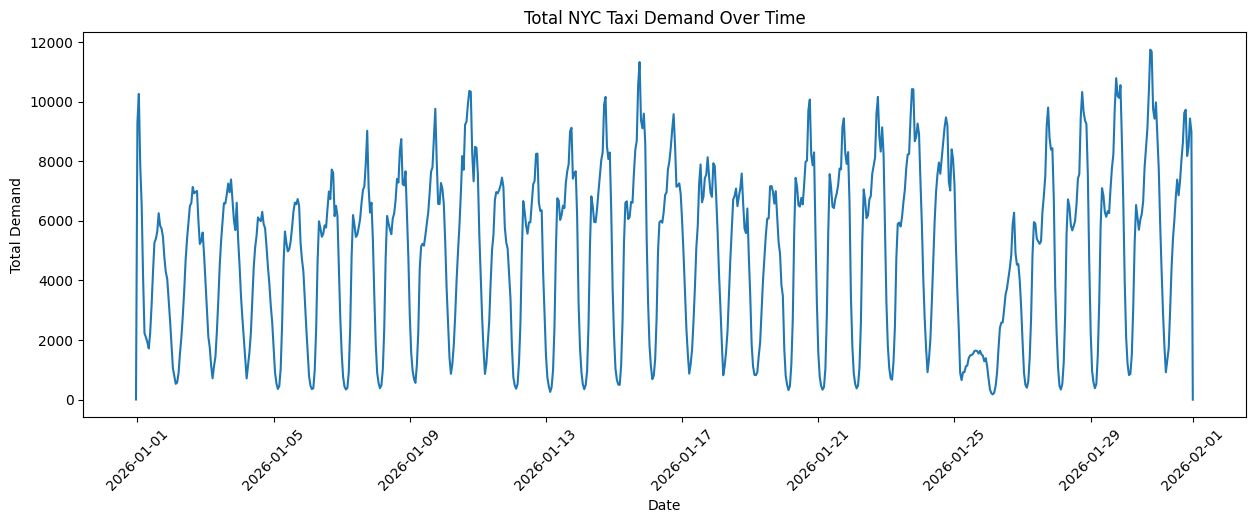

In [42]:
# How does overall taxi demand change across New York City?"
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    citywide_demand['hour'],
    citywide_demand['demand']
)

plt.title('Total NYC Taxi Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Total Demand')

plt.xticks(rotation=45)

plt.show()

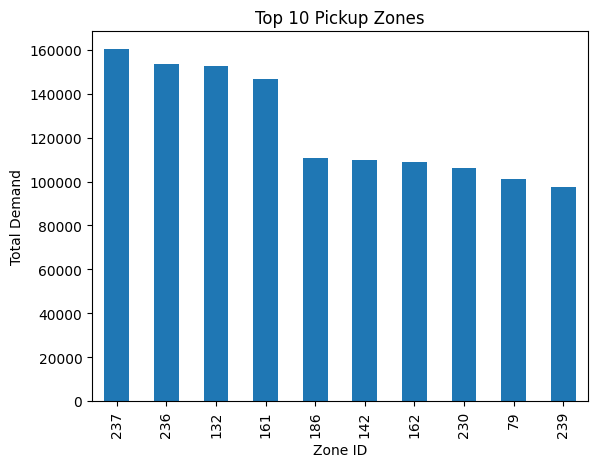

In [ ]:
# Top 10 Pickup Zones
top_zones = (
    hourly_demand
    .groupby('PULocationID')['demand']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


top_zones.plot(kind='bar')

plt.title('Top 10 Pickup Zones')
plt.xlabel('Zone ID')
plt.ylabel('Total Demand')
plt.show()

In [41]:
top_zones

PULocationID
237    160343
236    153640
132    152589
161    146641
186    110700
142    110004
162    108703
230    106114
79     100998
239     97465
Name: demand, dtype: int64

In [24]:

hourly_demand['hour_of_day'] = (
    hourly_demand['hour'].dt.hour
)

In [33]:
hourly_demand

,hour,PULocationID,demand,hour_of_day,day_of_week
0,2025-12-31 23:00:00,113,1,23,Wednesday
1,2025-12-31 23:00:00,132,3,23,Wednesday
2,2025-12-31 23:00:00,163,1,23,Wednesday
3,2025-12-31 23:00:00,164,1,23,Wednesday
4,2026-01-01 00:00:00,3,2,0,Thursday
...,...,...,...,...,...
123598,2026-01-31 23:00:00,261,29,23,Saturday
123599,2026-01-31 23:00:00,262,59,23,Saturday
123600,2026-01-31 23:00:00,263,175,23,Saturday
123601,2026-01-31 23:00:00,264,5,23,Saturday


In [26]:
# Analyze Hourly Demand Pattern
avg_hourly_demand = (
    hourly_demand
    .groupby('hour_of_day')['demand']
    .mean()
)
avg_hourly_demand
# On average, which hours of the day have the highest taxi demand?

hour_of_day
0     24.580751
1     20.393344
2     15.454156
3     11.133679
4      6.974702
5      6.577138
6     11.068438
7     18.670890
8     24.280498
9     26.583192
10    28.269527
11    30.540459
12    33.191960
13    34.577385
14    36.195186
15    39.089579
16    41.158208
17    45.824641
18    49.053195
19    45.925592
20    43.534356
21    43.986755
22    39.274395
23    30.408846
Name: demand, dtype: float64

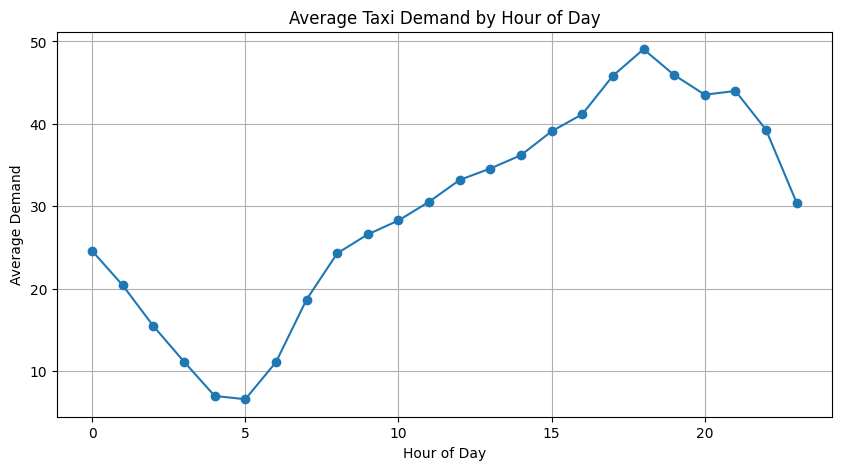

In [27]:

plt.figure(figsize=(10, 5))
avg_hourly_demand.plot(marker='o')

plt.title('Average Taxi Demand by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.grid(True)

plt.show()




In [28]:
hourly_demand['day_of_week'] = (
    hourly_demand['hour'].dt.day_name()
)

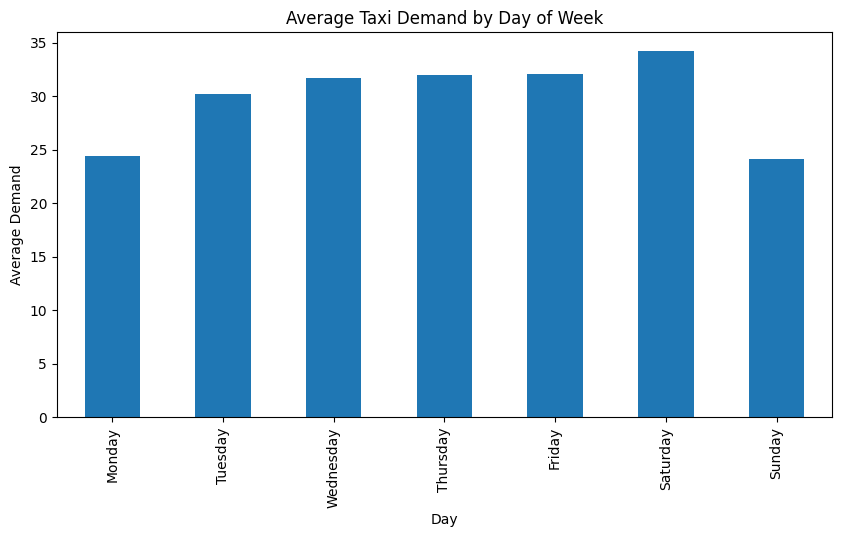

In [29]:
# Average Taxi Demand by Day of Week
days_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

avg_day_demand = (
    hourly_demand
    .groupby('day_of_week')['demand']
    .mean()
    .reindex(days_order)
)

plt.figure(figsize=(10, 5))
avg_day_demand.plot(kind='bar')

plt.title('Average Taxi Demand by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Demand')

plt.show()

In [31]:
zone_id = 161

zone_data = (
    hourly_demand[
        hourly_demand['PULocationID'] == zone_id
    ]
)
zone_data.head()


,hour,PULocationID,demand,hour_of_day,day_of_week
120,2026-01-01 00:00:00,161,261,0,Thursday
335,2026-01-01 01:00:00,161,255,1,Thursday
547,2026-01-01 02:00:00,161,162,2,Thursday
754,2026-01-01 03:00:00,161,60,3,Thursday
946,2026-01-01 04:00:00,161,17,4,Thursday


,hour,PULocationID,demand,hour_of_day,day_of_week,day_num
426,2026-01-01 02:00:00,1,1,2,Thursday,3
839,2026-01-01 04:00:00,1,3,4,Thursday,3
1021,2026-01-01 05:00:00,1,5,5,Thursday,3
1200,2026-01-01 06:00:00,1,2,6,Thursday,3
1395,2026-01-01 07:00:00,1,2,7,Thursday,3
1586,2026-01-01 08:00:00,1,1,8,Thursday,3
1757,2026-01-01 09:00:00,1,2,9,Thursday,3
2097,2026-01-01 11:00:00,1,2,11,Thursday,3
2265,2026-01-01 12:00:00,1,3,12,Thursday,3
2451,2026-01-01 13:00:00,1,4,13,Thursday,3


426       NaN
839       1.0
1021      3.0
1200      5.0
1395      2.0
         ... 
122324    2.0
122503    3.0
123064    2.0
123239    1.0
123418    1.0
Name: lag_1, Length: 123603, dtype: float64

426       NaN
839       NaN
1021      NaN
1200      NaN
1395      NaN
         ... 
122324    6.0
122503    3.0
123064    3.0
123239    3.0
123418    1.0
Name: lag_24, Length: 123603, dtype: float64